# Section 1 — Assignment 1
# Programming Fundamentals & Supervised Learning

**IOAI 2026 Preparation**

**Topics:** Python, NumPy, Pandas, Matplotlib, Scikit-learn, Linear Regression, Logistic Regression, L1/L2 Regularization, K-NN, Decision Trees, SVM

**Instructions:**
- Write all your code in the empty cells provided below each question.
- You may add extra cells if needed.
- Show all plots inline.
- Answer written questions as comments or in a new markdown cell.

---
## Problem 1 — NumPy Fundamentals

1. Create a 5×5 matrix of random integers between 1 and 100. Compute and print its row-wise mean, column-wise standard deviation, and the index (row, column) of the largest element.

2. Given arrays `a = [2, 4, 6, 8]` and `b = [1, 3, 5, 7]`, compute their dot product, element-wise product, and concatenate them into a single array of length 8.

3. Reshape a 1-D array of integers from 1 to 24 into a 3-dimensional array of shape (2, 3, 4). Then extract the second 3×4 slice and compute its transpose.

In [ ]:
import numpy as np
np.random.seed(42)
mat=np.random.randint(1,100,size=(5,5))
display(mat)

array([[52, 93, 15, 72, 61],
       [21, 83, 87, 75, 75],
       [88, 24,  3, 22, 53],
       [ 2, 88, 30, 38,  2],
       [64, 60, 21, 33, 76]])

In [ ]:
row_mean=np.mean(mat,axis=1)
display(row_mean)

array([58.6, 68.2, 38. , 32. , 50.8])

In [ ]:
col_std=np.std(mat,axis=0)
display(col_std)

array([30.60457482, 25.44484231, 29.24653826, 21.47556751, 27.11899703])

In [ ]:
idx=np.argmax(mat)
row,col=np.unravel_index(idx,mat.shape)
print(row,col)

0 1


---
## Problem 2 — Pandas Data Manipulation

Create the following DataFrame manually:

| name   | math | science | english | grade |
|--------|------|---------|---------|-------|
| Alice  | 88   | 92      | NaN     | A     |
| Bob    | 72   | NaN     | 65      | B     |
| Carol  | 95   | 89      | 91      | A     |
| David  | NaN  | 74      | 70      | B     |
| Eve    | 60   | 55      | 58      | C     |
| Frank  | 84   | 80      | NaN     | A     |

Then:
1. Fill all missing numeric values with the mean of their respective column.
2. Add a new column `average` which is the mean of math, science, and english for each student.
3. Print the average score grouped by `grade`.
4. Sort the DataFrame by `average` in descending order and display the top 3 students.
5. Filter and display only students whose `average` is above 80.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data={
    "name":["Alice","Bob","Carol","David","Eve","Frank"],
    "math":[88,72,95,np.nan,60,84],
    "science":[92,np.nan,89,74,55,60],
    "english":[np.nan,65,91,70,58,np.nan],
    "grade":["A","B","A","B","C","A"]
}
df=pd.DataFrame(data)
display(df)

,name,math,science,english,grade
0,Alice,88.0,92.0,NaN,A
1,Bob,72.0,NaN,65.0,B
2,Carol,95.0,89.0,91.0,A
3,David,NaN,74.0,70.0,B
4,Eve,60.0,55.0,58.0,C
5,Frank,84.0,60.0,NaN,A


In [ ]:
x=df['math'].mean()
y=df['science'].mean()
z=df['english'].mean()
df['math'].fillna(x,inplace=True)
df['science'].fillna(y,inplace=True)
df['english'].fillna(z,inplace=True)
display(df)

/tmp/ipykernel_2595/3614964943.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['math'].fillna(x,inplace=True)
/tmp/ipykernel_2595/3614964943.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.metho

,name,math,science,english,grade
0,Alice,88.0,92.0,71.0,A
1,Bob,72.0,74.0,65.0,B
2,Carol,95.0,89.0,91.0,A
3,David,79.8,74.0,70.0,B
4,Eve,60.0,55.0,58.0,C
5,Frank,84.0,60.0,71.0,A


In [ ]:
df['Avg']=df[['math','science','english']].mean(axis=1)
display(df)

,name,math,science,english,grade,Avg
0,Alice,88.0,92.0,71.0,A,83.666667
1,Bob,72.0,74.0,65.0,B,70.333333
2,Carol,95.0,89.0,91.0,A,91.666667
3,David,79.8,74.0,70.0,B,74.600000
4,Eve,60.0,55.0,58.0,C,57.666667
5,Frank,84.0,60.0,71.0,A,71.666667


In [ ]:
display(df.sort_values(by='Avg',ascending=False).head(3))

,name,math,science,english,grade,Avg
2,Carol,95.0,89.0,91.0,A,91.666667
0,Alice,88.0,92.0,71.0,A,83.666667
3,David,79.8,74.0,70.0,B,74.600000


In [ ]:
display(df[df['Avg']>80])

,name,math,science,english,grade,Avg
0,Alice,88.0,92.0,71.0,A,83.666667
2,Carol,95.0,89.0,91.0,A,91.666667


---
## Problem 3 — Matplotlib & Seaborn Visualization

Using the DataFrame from Problem 2:

1. Create a figure with two subplots side by side:
   - Left: A **bar chart** showing the `average` score for each student, colored by grade (A=green, B=blue, C=red).
   - Right: A **heatmap** (using Seaborn) of the numeric columns (math, science, english), with annotations showing the values.

2. In a separate figure, create a **scatter plot** of `math` vs `science` scores. Size each point proportional to the student's `average` score. Label each point with the student's name.

3. Add proper titles, axis labels, and a legend to all plots.

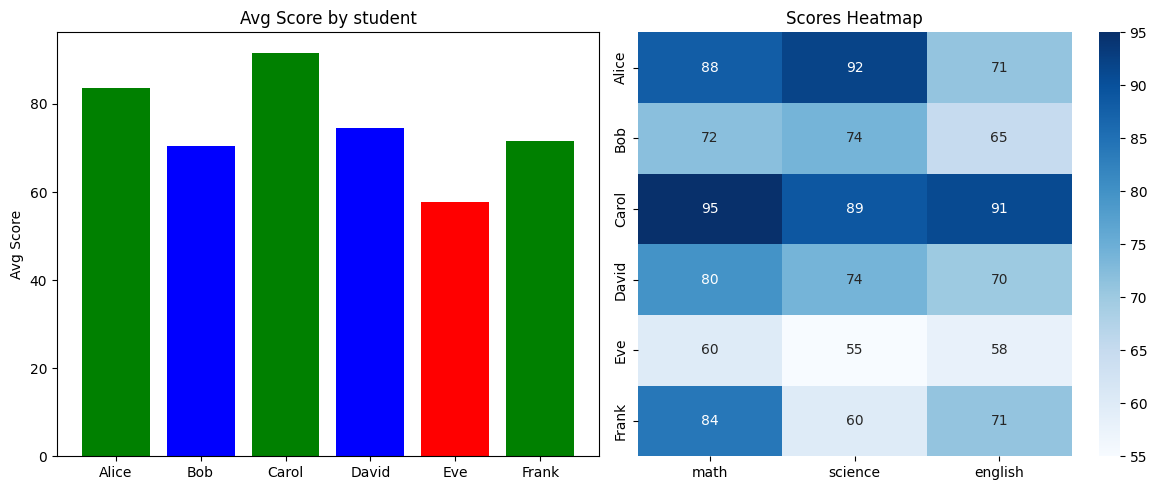

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = df["grade"].map({"A": "green", "B": "blue", "C": "red"})
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(df["name"], df["Avg"], color=colors)
axes[0].set_title("Avg Score by student")
axes[0].set_ylabel("Avg Score")
sns.heatmap(
    df[["math", "science", "english"]], annot=True, yticklabels=df["name"], ax=axes[1], cmap="Blues",)
axes[1].set_title("Scores Heatmap")
plt.tight_layout()
plt.show()

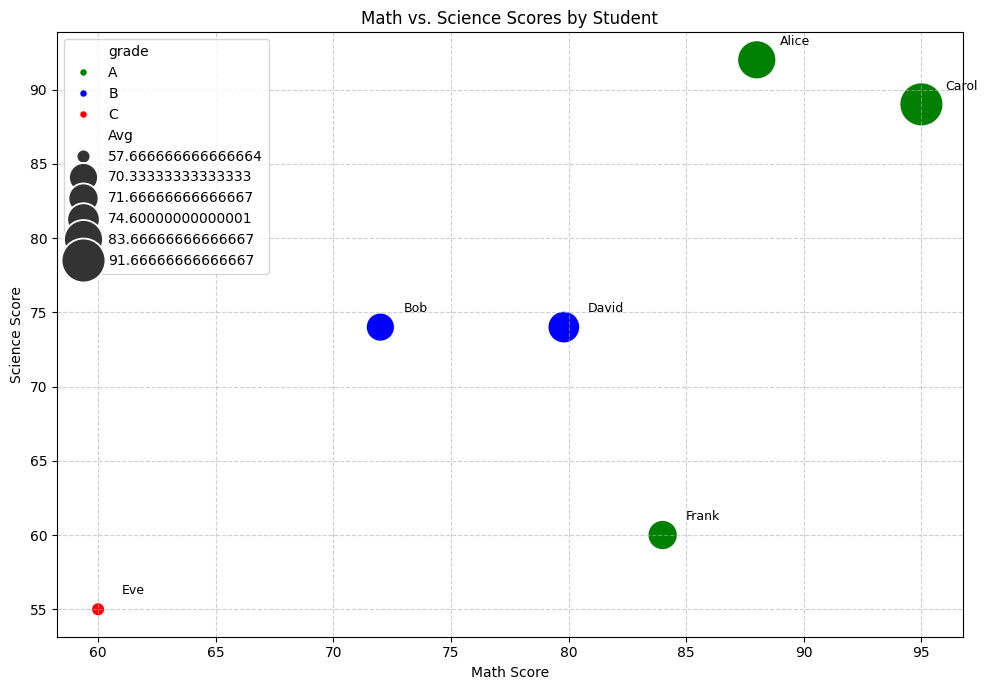

In [ ]:
fig2, ax2 = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    x='math',
    y='science',
    size='Avg',
    sizes=(100, 1000),
    hue='grade',
    data=df,
    ax=ax2,
    palette=colors.unique().tolist(),
    legend='full' )
for i, row in df.iterrows():
    ax2.text(row['math'] + 1, row['science'] + 1, row['name'], fontsize=9)
ax2.set_title('Math vs. Science Scores by Student')
ax2.set_xlabel('Math Score')
ax2.set_ylabel('Science Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
## Problem 4 — Linear Regression From Scratch

Implement simple linear regression using **batch gradient descent** — do NOT use any sklearn function for this problem.

1. Generate a synthetic dataset: `x` as 100 evenly spaced points in [0, 10], and `y = 4x + 3 + noise` where noise ~ N(0, 2).

2. Implement a function `gradient_descent(X, y, lr, epochs)` that:
   - Initializes weights `w` and bias `b` to zero.
   - At each step computes the MSE loss and its gradients with respect to `w` and `b`.
   - Updates `w` and `b` using gradient descent.
   - Returns the learned `w`, `b`, and the loss history.

3. Train for 1000 epochs with a learning rate of 0.01. Print the final `w` and `b` (they should be close to 4 and 3).

4. Plot: (a) the loss curve over epochs, (b) the original data points and the fitted regression line.

5. Now try learning rates of 0.001, 0.01, and 0.1. Plot all three loss curves on the same graph and discuss the effect.

In [ ]:
np.random.seed(42)
x=np.linspace(0,10,100)
noise=np.random.normal(0,2,100)
y=4*x+3+noise

In [ ]:
def grad_des(X, y, lr, epochs):
    m = len(y)

    if X.ndim == 1:
        X = X.reshape(-1, 1)
    y = y.reshape(-1, 1)
    w = 0.0
    b = 0.0
    loss_his = []
    for epoch in range(epochs):
        y_pred = X * w + b
        error = y_pred - y
        mse_loss = np.mean(error**2)
        loss_his.append(mse_loss)
        grad_w = (2/m) * np.sum(error * X)
        grad_b = (2/m) * np.sum(error)

        w = w - lr * grad_w
        b = b - lr * grad_b
    return w, b, loss_his

In [ ]:
lr_1 = 0.01
epochs_1 = 1000
w_tr, b_tr, loss_his_1 = grad_des(x, y, lr_1, epochs_1)
print(f"Final weight: {w_tr:.4f}")
print(f"Final bias: {b_tr:.4f}")

Final weight: 4.0297
Final bias: 2.6406


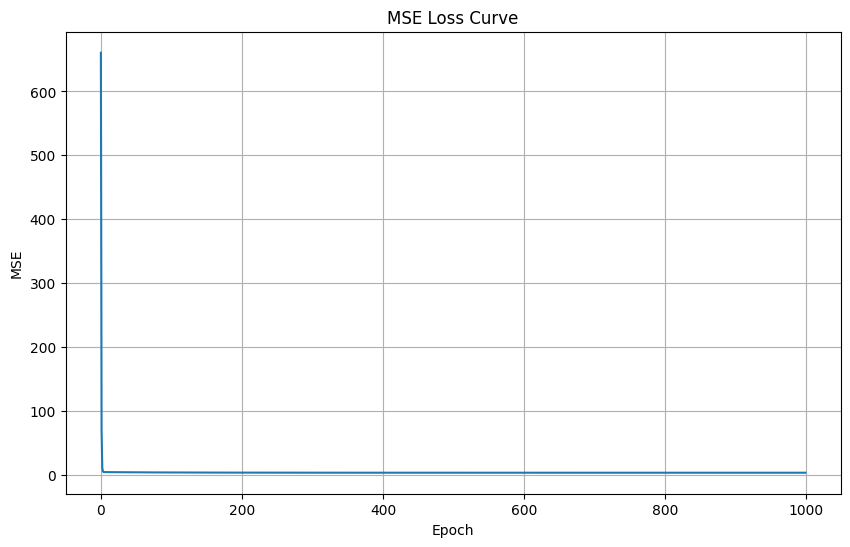

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(epochs_1), loss_his_1)
plt.title('MSE Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.grid(True)
plt.show()

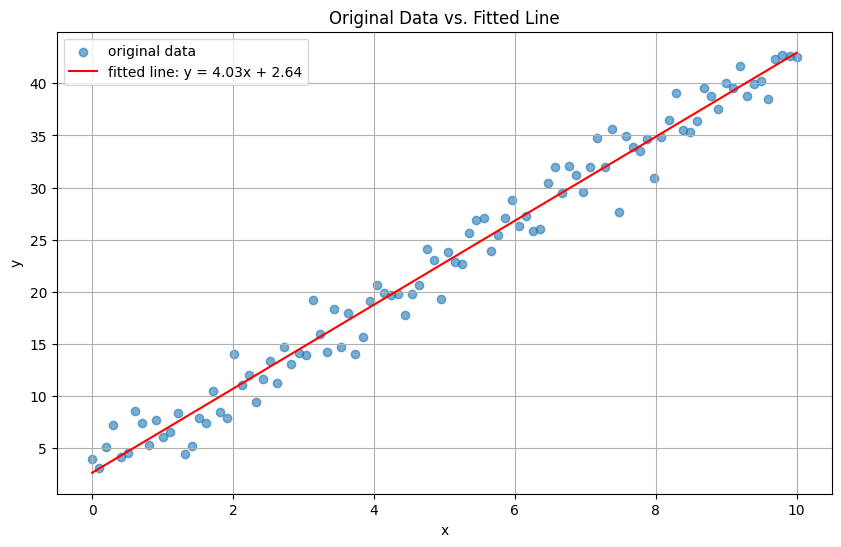

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='original data', alpha=0.6)
x_plot = np.linspace(0, 10, 100)
y_pred_plot = x_plot * w_tr + b_tr
plt.plot(x_plot, y_pred_plot, color='red', label=f'fitted line: y = {w_tr:.2f}x + {b_tr:.2f}')

plt.title('Original Data vs. Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

training with: 0.001
training with: 0.01
training with: 0.1


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_2595/1247753512.py:13: RuntimeWarning: overflow encountered in square
  mse_loss = np.mean(error**2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_2595/1247753512.py:11: RuntimeWarning: invalid value encountered in multiply
  y_pred = X * w + b


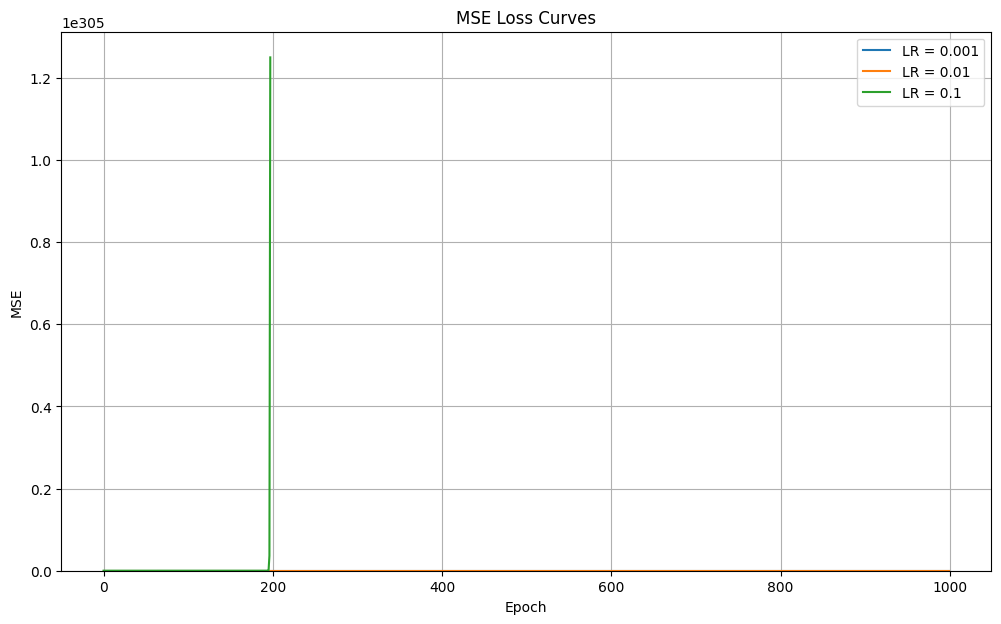

In [ ]:
lr_rates = [0.001, 0.01, 0.1]
epochs = 1000
loss_his = {}

for lr in lr_rates:
    print(f"training with: {lr}")
    _, _, history = grad_des(x, y, lr, epochs)
    loss_his[lr] = history

plt.figure(figsize=(12, 7))
for lr, history in loss_his.items():
    plt.plot(range(epochs), history, label=f'LR = {lr}')

plt.title('MSE Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
plt.show()

---
## Problem 5 — Logistic Regression & Regularization

Use the **Iris dataset** from `sklearn.datasets`.

1. Extract only classes **Versicolor** and **Virginica** (target values 1 and 2). Use all 4 features. Split into 80% train / 20% test.

2. Train three Logistic Regression models:
   - No regularization (set `C` to a very large number)
   - L2 regularization with `C = 0.01`
   - L1 regularization with `C = 0.01` (use `solver='liblinear'`)

3. For each model, print: train accuracy, test accuracy, and the learned coefficients.

4. Create a bar chart comparing the coefficients of all three models across the 4 features. What do you observe about sparsity in L1 vs L2?

5. Answer: Why does strong regularization (small C) sometimes improve test accuracy despite reducing train accuracy?

### Problem 5 - Logistic Regression & Regularization

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

In [ ]:
mask = (y == 1) | (y == 0)
X_fil = X[mask]
y_fil = y[mask]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_fil, y_fil, test_size=0.2, random_state=42, stratify=y_fil)

In [ ]:
print(f"shape of X: {X_fil.shape}")
print(f"shape of y: {y_fil.shape}")
print(f"shape of X_train: {X_train.shape}")
print(f"shape of X_test: {X_test.shape}")

shape of X: (100, 4)
shape of y: (100,)
shape of X_train: (80, 4)
shape of X_test: (20, 4)


In [ ]:
model_no_reg = LogisticRegression(penalty='l2', C=1e9, solver='lbfgs', max_iter=1000, random_state=42)
model_no_reg.fit(X_train, y_train)

model_l2 = LogisticRegression(penalty='l2', C=0.01, solver='lbfgs', max_iter=1000, random_state=42)
model_l2.fit(X_train, y_train)

model_l1 = LogisticRegression(penalty='l1', C=0.01, solver='liblinear', max_iter=1000, random_state=42)
model_l1.fit(X_train, y_train)

models = {
    'no reg': model_no_reg,
    'L2 reg': model_l2,
    'L1 reg': model_l1
}
feature= iris.feature_names

for name, model in models.items():
    print(f"\n{name}")
    print(f"Train Acc: {model.score(X_train, y_train):.4f}")
    print(f"Test Acc: {model.score(X_test, y_test):.4f}")
    print("Coefficients:")
    for i, coef_val in enumerate(model.coef_[0]):
        print(f"  {feature[i]}: {coef_val:.4f}")
    print(f"Intercept: {model.intercept_[0]:.4f}")


no reg
Train Acc: 1.0000
Test Acc: 1.0000
Coefficients:
  sepal length (cm): -1.1368
  sepal width (cm): -4.4186
  petal length (cm): 6.5952
  petal width (cm): 3.2769
Intercept: -0.7082

L2 reg
Train Acc: 1.0000
Test Acc: 1.0000
Coefficients:
  sepal length (cm): 0.1203
  sepal width (cm): -0.0928
  petal length (cm): 0.3671
  petal width (cm): 0.1414
Intercept: -1.5301

L1 reg
Train Acc: 0.5000
Test Acc: 0.5000
Coefficients:
  sepal length (cm): 0.0000
  sepal width (cm): 0.0000
  petal length (cm): 0.0000
  petal width (cm): 0.0000
Intercept: 0.0000


/tmp/ipykernel_2595/3098240268.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')


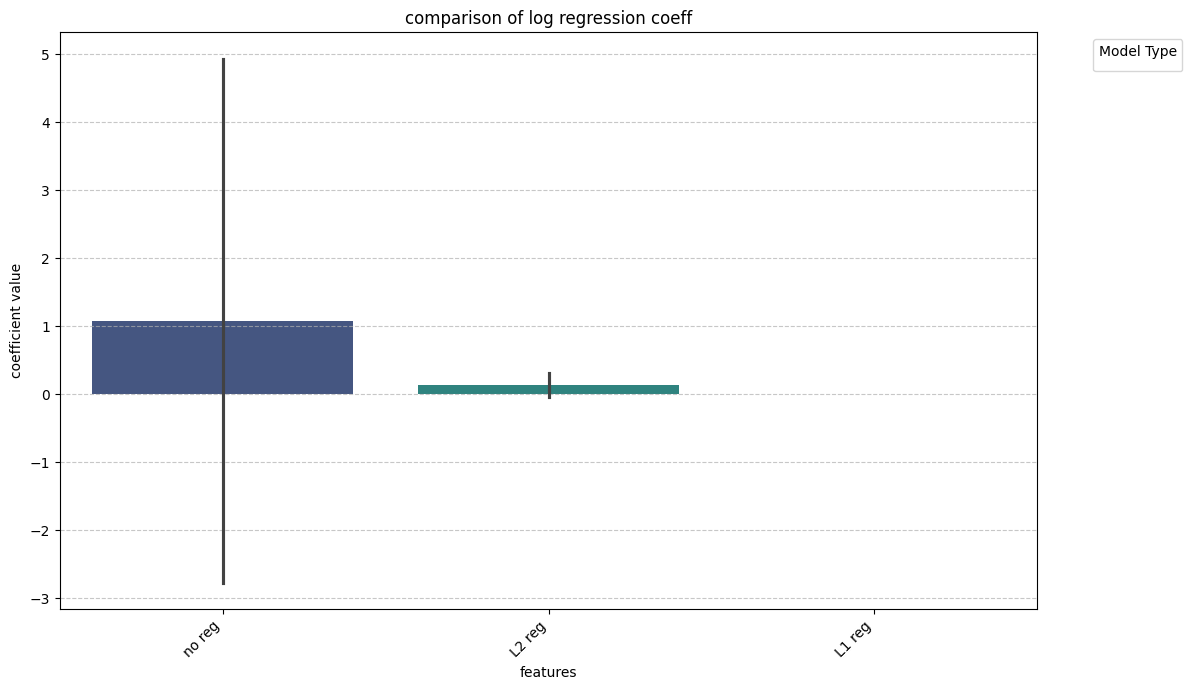

In [ ]:
coefs = []
labels = []
for name, model in models.items():
    coefs.append(model.coef_[0])
    labels.append(name)
coef_df = pd.DataFrame(coefs, columns=feature, index=labels)

plt.figure(figsize=(12, 7))
sns.barplot(data=coef_df.T, palette='viridis')
plt.title('comparison of log regression coeff')
plt.xlabel('features')
plt.ylabel('coefficient value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---

### 4. For the best k, visualize the decision boundary

---

---
## Problem 6 — K-Nearest Neighbors

1. Generate a binary classification dataset with 600 samples and 2 features using `make_classification` (set `n_redundant=0`, `n_informative=2`). Split 75% train / 25% test.

2. Train K-NN classifiers for k = 1, 3, 5, 7, 11, 15, 21. For each, record train and test accuracy.

3. Plot train accuracy and test accuracy vs k on the same graph. Identify the best k for generalization.

4. For the best k, visualize the **decision boundary** using a mesh grid. Color the background by predicted class and overlay the data points.

5. What does k=1 imply about the model? What happens as k approaches the total number of training samples?

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X_knn, y_knn = make_classification(n_samples=600, n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_knn, y_knn, test_size=0.25, random_state=42, stratify=y_knn)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
k_values = [1, 3, 5, 7, 11, 15, 21]
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accuracies.append(knn.score(X_train, y_train))
    test_accuracies.append(knn.score(X_test, y_test))
    print(f"Train Accuracy = {train_accuracies[-1]:.4f}, Test Accuracy = {test_accuracies[-1]:.4f}")

Train Accuracy = 1.0000, Test Accuracy = 0.9400
Train Accuracy = 0.9689, Test Accuracy = 0.9533
Train Accuracy = 0.9667, Test Accuracy = 0.9533
Train Accuracy = 0.9667, Test Accuracy = 0.9533
Train Accuracy = 0.9667, Test Accuracy = 0.9467
Train Accuracy = 0.9644, Test Accuracy = 0.9467
Train Accuracy = 0.9644, Test Accuracy = 0.9467


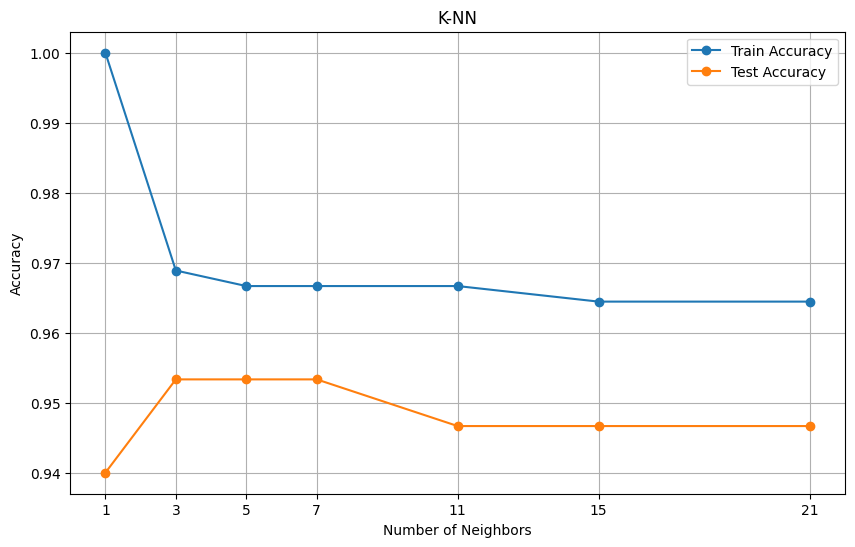

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='o')
plt.title('K-NN')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_k_idx = np.argmax(test_accuracies)
best_k = k_values[best_k_idx]
best_test_accuracy = test_accuracies[best_k_idx]
print(f"\nBest k: {best_k} (Test Accuracy: {best_test_accuracy:.4f})")
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)


Best k: 3 (Test Accuracy: 0.9533)


KNeighborsClassifier(n_neighbors=3)

In [ ]:
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
x_min, x_max = X_knn[:, 0].min() - 1, X_knn[:, 0].max() + 1
y_min, y_max = X_knn[:, 1].min() - 1, X_knn[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = best_knn.predict(np.c_[xx.ravel(), yy.ravel()])

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


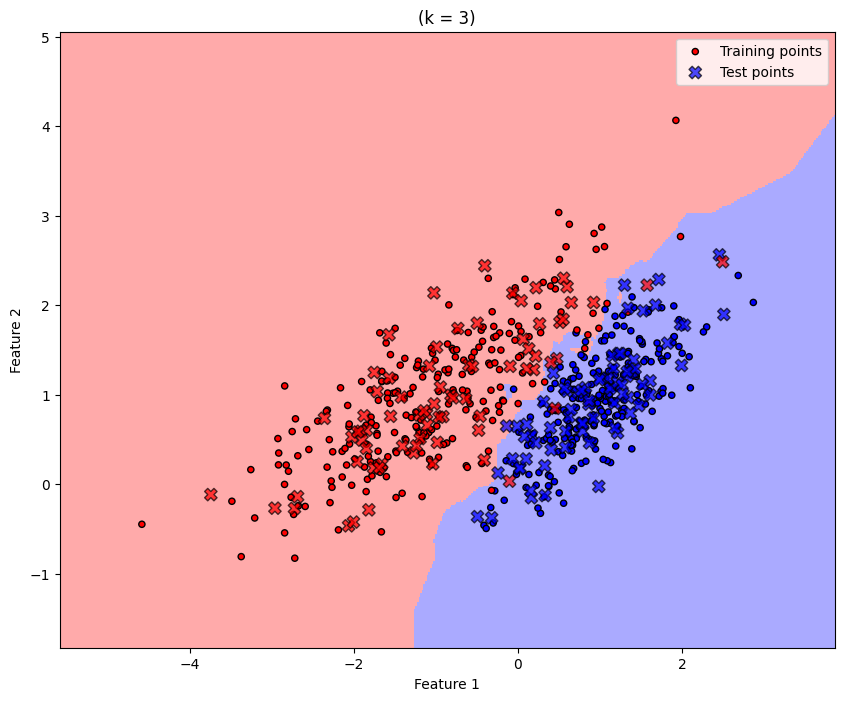

In [ ]:
Z = Z.reshape(xx.shape)
plt.figure(figsize=(10, 8))
plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=20, label='Training points')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cmap_bold, edgecolor='k', s=80, marker='X', alpha=0.7, label='Test points')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title(f"(k = {best_k})")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

---
## Problem 7 — Decision Trees

Use the full **Iris dataset** (3 classes, 4 features).

1. Train a `DecisionTreeClassifier` with `max_depth=4` and `criterion='gini'`. Report train and test accuracy.

2. Visualize the trained decision tree using `plot_tree`. Include feature names and class names.

3. Plot feature importances as a horizontal bar chart.

4. Train trees with `max_depth` ranging from 1 to 12. Plot both train and test accuracy vs depth. At which depth does overfitting begin?

5. Now train a tree with `criterion='entropy'` at the best depth from step 4. Compare accuracy with the gini tree. Which performs better and why might that be?

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
iris_dt = load_iris()
X_dt = iris_dt.data
y_dt = iris_dt.target
feature_names_dt = iris_dt.feature_names
class_names_dt = iris_dt.target_names

In [ ]:
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y_dt, test_size=0.25, random_state=42, stratify=y_dt)

In [ ]:
dt_gini = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
dt_gini.fit(X_train_dt, y_train_dt)

train_acc_gini = dt_gini.score(X_train_dt, y_train_dt)
test_acc_gini = dt_gini.score(X_test_dt, y_test_dt)

In [ ]:
print(f"Train Accuracy: {train_acc_gini:.4f}")
print(f"Test Accuracy: {test_acc_gini:.4f}")

Train Accuracy: 0.9911
Test Accuracy: 0.9211


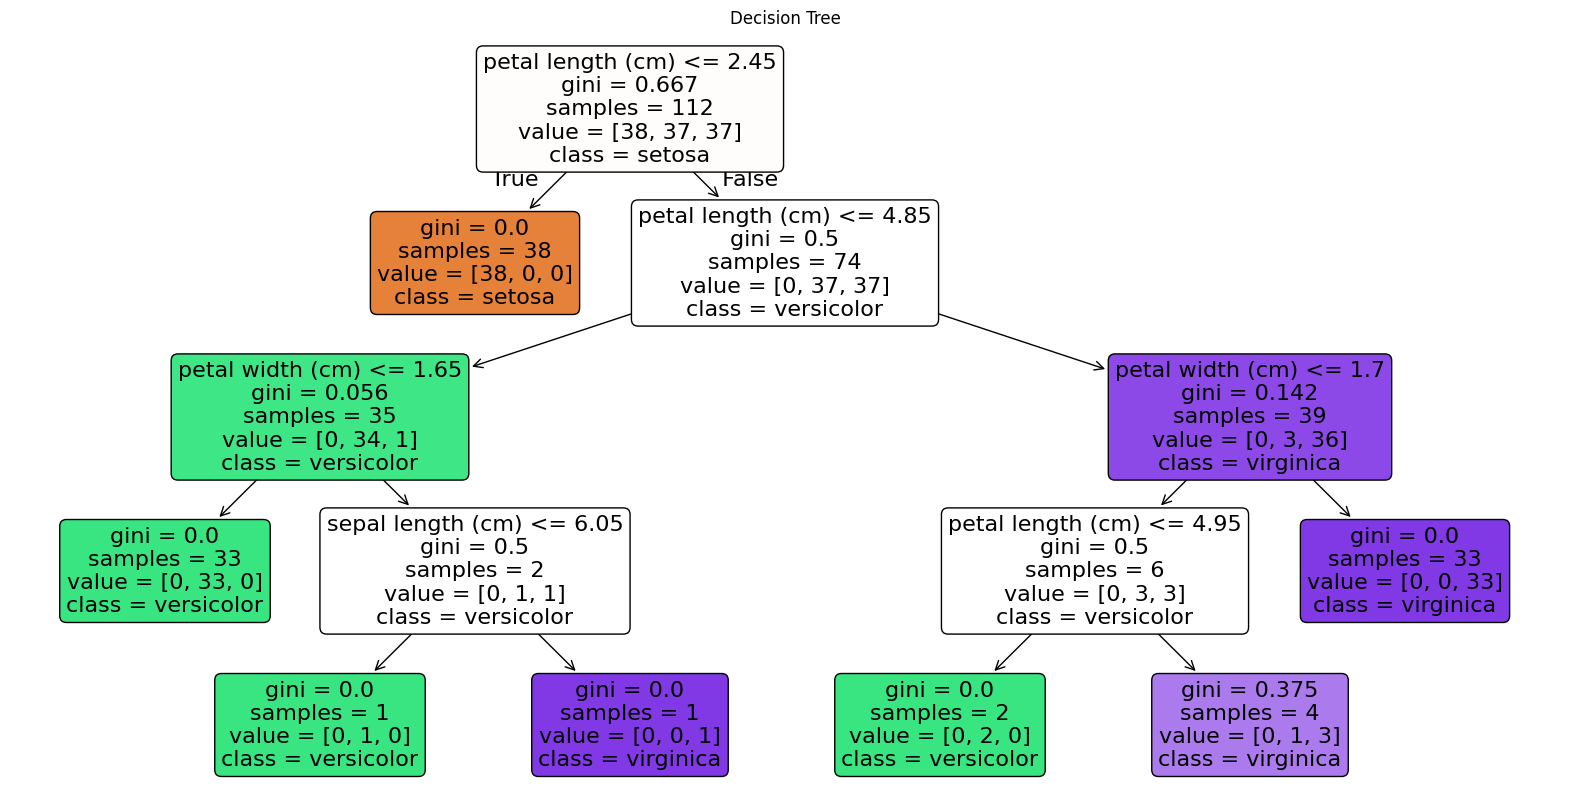

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(dt_gini, filled=True, feature_names=feature_names_dt, class_names=class_names_dt, rounded=True)
plt.title('Decision Tree')
plt.show()
feature_importances = dt_gini.feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names_dt, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

/tmp/ipykernel_2595/3228993541.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


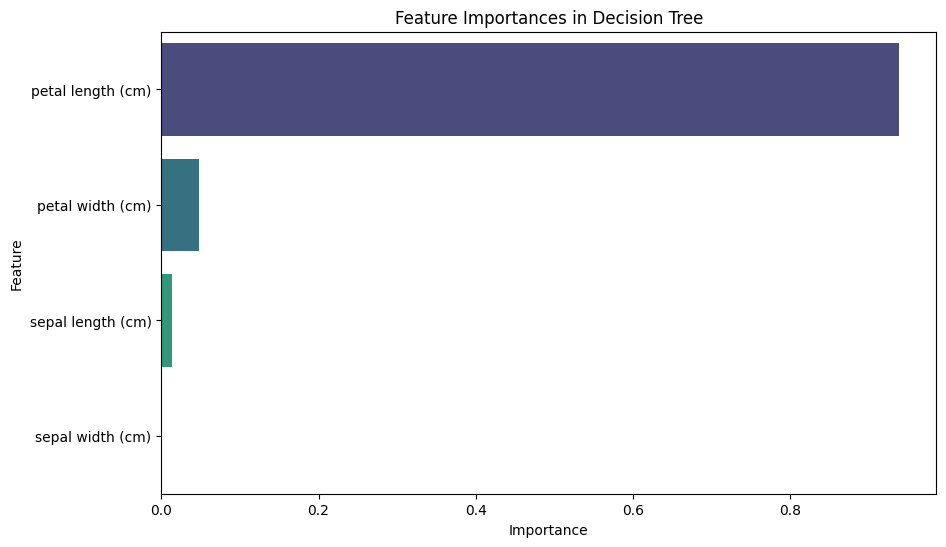

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importances in Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
depths = range(1, 13)
train_accuracies_depth = []
test_accuracies_depth = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, criterion='gini', random_state=42)
    dt.fit(X_train_dt, y_train_dt)
    train_accuracies_depth.append(dt.score(X_train_dt, y_train_dt))
    test_accuracies_depth.append(dt.score(X_test_dt, y_test_dt))

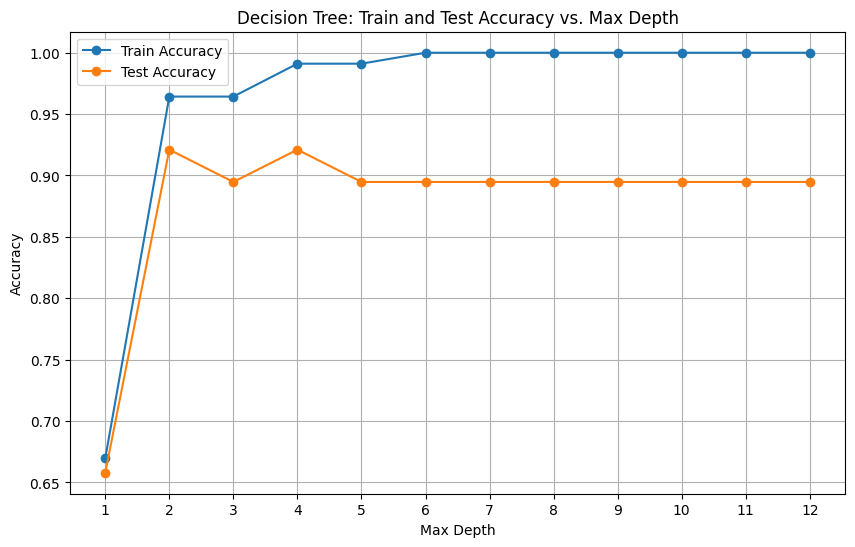

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies_depth, label='Train Accuracy', marker='o')
plt.plot(depths, test_accuracies_depth, label='Test Accuracy', marker='o')
plt.title('Decision Tree: Train and Test Accuracy vs. Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_depth = 5
dt_entropy = DecisionTreeClassifier(max_depth=best_depth, criterion='entropy', random_state=42)
dt_entropy.fit(X_train_dt, y_train_dt)
train_acc_entropy = dt_entropy.score(X_train_dt, y_train_dt)
test_acc_entropy = dt_entropy.score(X_test_dt, y_test_dt)

In [ ]:
print(f"Train Accuracy: {train_accuracies_depth[best_depth-1]:.4f}")
print(f"Test Accuracy: {test_accuracies_depth[best_depth-1]:.4f}")
print(f"Train Accuracy: {train_acc_entropy:.4f}")
print(f"Test Accuracy: {test_acc_entropy:.4f}")

Train Accuracy: 0.9911
Test Accuracy: 0.8947
Train Accuracy: 0.9911
Test Accuracy: 0.8947


---
## Problem 8 — Support Vector Machines

1. Generate a **non-linearly separable** dataset using `make_circles` (n_samples=300, noise=0.1). Split 80/20.

2. Train three SVM classifiers with kernels: `linear`, `poly` (degree=3), and `rbf`. Scale the features before training.

3. Report test accuracy for each kernel and visualize all three decision boundaries side by side.

4. For the RBF kernel, experiment with `C` = [0.01, 1, 10, 100] and `gamma` = ['scale', 0.01, 0.1, 1]. Build a 4×4 grid and plot test accuracy for each combination as a heatmap.

5. Explain in your own words: What is the role of the **kernel trick** in SVM? What does the parameter `C` control?

In [ ]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
X, y = make_circles(n_samples=300, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (240, 2)
Shape of X_test: (60, 2)


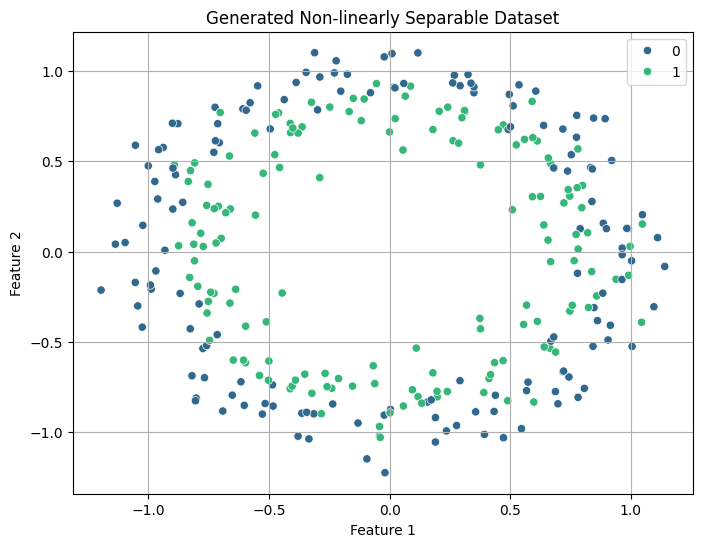

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis')
plt.title('Generated Non-linearly Separable Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
svm_linear = SVC(kernel='linear', random_state=42)
svm_poly = SVC(kernel='poly', degree=3, random_state=42)
svm_rbf = SVC(kernel='rbf', random_state=42)

In [ ]:
svm_linear.fit(X_train_scaled, y_train)
svm_poly.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

models = {
    'Linear Kernel': svm_linear,
    'Polynomial Kernel (deg=3)': svm_poly,
    'RBF Kernel': svm_rbf
}

In [ ]:
def plot_decision_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel('Scaled Feature 1')
    ax.set_ylabel('Scaled Feature 2')
    ax.set_xticks(())
    ax.set_yticks(())

Linear Kernel: Test Accuracy = 0.4333
Polynomial Kernel (deg=3): Test Accuracy = 0.4667
RBF Kernel: Test Accuracy = 0.8167


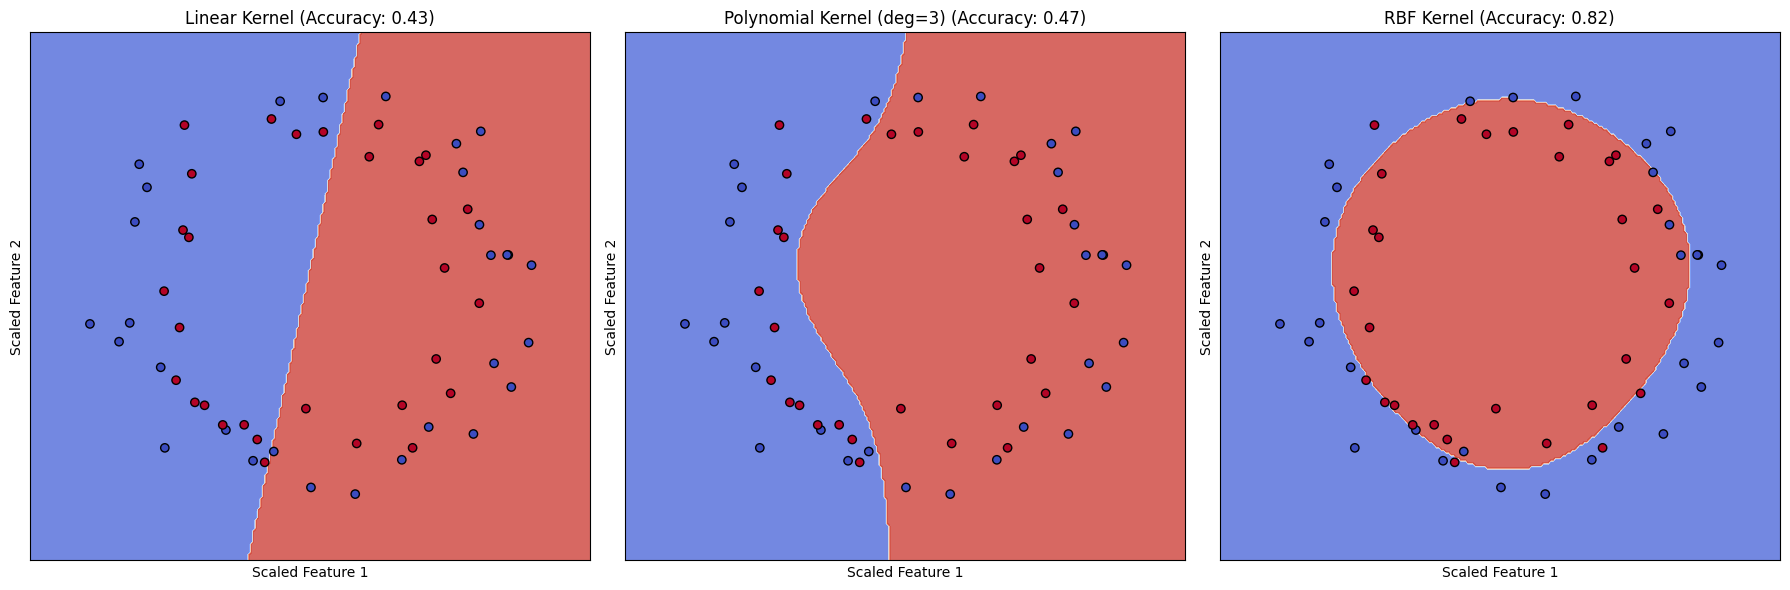

In [ ]:
plt.figure(figsize=(18, 6))
for i, (name, model) in enumerate(models.items()):
    test_acc = model.score(X_test_scaled, y_test)
    print(f"{name}: Test Accuracy = {test_acc:.4f}")

    ax = plt.subplot(1, 3, i + 1)
    plot_decision_boundary(ax, model, X_test_scaled, y_test, f"{name} (Accuracy: {test_acc:.2f})")

plt.tight_layout()
plt.show()

In [ ]:
C_values = [0.01, 1, 10, 100]
gamma_values = ['scale', 0.01, 0.1, 1]
accuracies_heatmap = np.zeros((len(C_values), len(gamma_values)))

for i, C in enumerate(C_values):
    for j, gamma in enumerate(gamma_values):
        svm_rbf_tuned = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
        svm_rbf_tuned.fit(X_train_scaled, y_train)
        accuracies_heatmap[i, j] = svm_rbf_tuned.score(X_test_scaled, y_test)

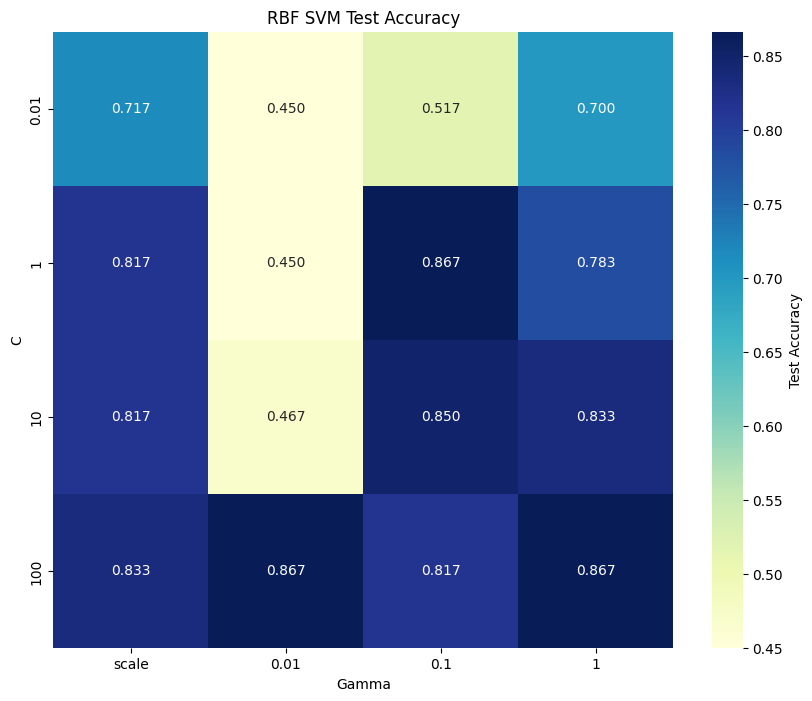

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    accuracies_heatmap,
    annot=True,
    fmt=".3f",
    xticklabels=[str(g) for g in gamma_values],
    yticklabels=[str(c) for c in C_values],
    cmap="YlGnBu",
    cbar_kws={'label': 'Test Accuracy'}
)
plt.title('RBF SVM Test Accuracy')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.show()

---
## Reflection Questions

Answer the following in a new markdown cell or as comments:

1. What is the **bias-variance tradeoff**? Give one example from this assignment where you observed it.
2. Why is it important to **scale features** before training K-NN or SVM but not necessarily before Decision Trees?
3. When would you choose **Logistic Regression** over an **SVM**? When would you prefer the opposite?
4. What is the difference between **L1** and **L2** regularization in terms of the geometry of their constraint regions?



1.  
   It’s all about finding a sweet spot. High bias means the model is too simple and misses the actual patterns (underfitting). High variance means it's too complex and just memorizes the training data, noise and all (overfitting). You want something right in the middle that learns the actual trend.

   We saw this firsthand with K-NN in Problem 6. At k=1, the model had perfect training accuracy but worse test accuracy—classic overfitting/high variance because it was just looking at its closest single neighbor. Bumping k up to 3 usually improved the test accuracy by smoothing things out. If we made k way too large, it would go too far the other way, becoming too simple and suffering from high bias.

2.  
   K-NN and SVM are entirely based on calculating distances (like Euclidean distance or margins). If one feature has huge numbers (like salary) and another has tiny numbers (like age), the big numbers will completely hijack the math. Scaling puts everything on a level playing field.

   Decision Trees don't care about distances at all. They just split data based on "greater than or less than" thresholds for one feature at a time. Because they look at features individually rather than combining them into a distance metric, the scale doesn't change where the splits happen.
3.  
   I'd go with Logistic Regression if the dataset is massive, if I need clear probability scores instead of just hard classifications, or if I need to easily explain the model to stakeholders using the coefficients.

   SVMs are the move when the data isn't linearly separable and I need to use the "kernel trick" to find complex, non-linear boundaries. They're usually great for small-to-medium datasets where finding that maximum margin of separation gives you a really robust model.

4.
   It comes down to the shape of their constraint regions. L2 (Ridge) has a circular/spherical constraint region. Because it's smooth and round, the optimal weights usually hit somewhere along the curve, shrinking the coefficients close to zero but rarely exactly to zero.

   L1 (Lasso) has a diamond/polyhedral constraint region with sharp corners. Mathematically, the optimal solution is highly likely to hit one of these corners, which sit right on the axes. When a solution hits an axis, it forces some coefficients to become exactly zero, giving you a sparse model and doing automatic feature selection.